In [1]:
print("hello")

hello


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip -o /playground-series-s3e17.zip -d /content/data
!ls /content/data

Archive:  /playground-series-s3e17.zip
  inflating: /content/data/sample_submission.csv  
  inflating: /content/data/test.csv  
  inflating: /content/data/train.csv  
sample_submission.csv  test.csv  train.csv


In [4]:
import pandas as pd
df = pd.read_csv("/content/data/train.csv")
print(df.shape)
print(df.columns.tolist())
df.head()

(136429, 14)
['id', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [5]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()
df.columns = (df.columns.str.replace(r"\[.*?\]", "", regex=True)
              .str.strip().str.lower().str.replace(" ", "_"))

df["wear_band"] = pd.cut(df["tool_wear"], [-1,50,100,150,200,300],
                         labels=["0-50","51-100","101-150","151-200","200+"])

total = len(df)
failures = int(df["machine_failure"].sum())
print(f"Total: {total} | Failures: {failures} | Rate: {failures/total:.2%}")

print(df.groupby("type")["machine_failure"].agg(["count","sum","mean"]).round(4))
print(df.groupby("wear_band", observed=True)["machine_failure"].mean().round(4))
print(df[["twf","hdf","pwf","osf","rnf"]].sum().sort_values(ascending=False))

Missing values: 0
Duplicates: 0
Total: 136429 | Failures: 2148 | Rate: 1.57%
      count   sum    mean
type                     
H      8923   116  0.0130
L     95354  1595  0.0167
M     32152   437  0.0136
wear_band
0-50       0.0119
51-100     0.0106
101-150    0.0110
151-200    0.0159
200+       0.0740
Name: machine_failure, dtype: float64
hdf    704
osf    540
pwf    327
rnf    308
twf    212
dtype: int64


In [6]:
# Compare numerical features between failed and non-failed machines

numeric_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

df.groupby("Machine failure")[numeric_features].mean().T

KeyError: 'Machine failure'

In [7]:
summary = {
    "Total Records": len(df),
    "Total Failures": df["Machine failure"].sum(),
    "Failure Rate (%)": round(df["Machine failure"].mean() * 100, 2),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum()
}

pd.Series(summary)

KeyError: 'Machine failure'

In [8]:
print(df.columns.tolist())

['id', 'product_id', 'type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'wear_band']


In [9]:
summary = {
    "Total Records": len(df),
    "Total Failures": df["machine_failure"].sum(),
    "Failure Rate (%)": round(df["machine_failure"].mean() * 100, 2),
    "Missing Values": df.isnull().sum().sum(),
    "Duplicate Rows": df.duplicated().sum()
}

pd.Series(summary)

,0
Total Records,136429.00
Total Failures,2148.00
Failure Rate (%),1.57
Missing Values,0.00
Duplicate Rows,0.00


In [10]:
type_analysis = (
    df.groupby("Type")
      .agg(
          total_records=("machine_failure", "size"),
          failures=("machine_failure", "sum"),
          failure_rate=("machine_failure", "mean")
      )
      .reset_index()
)

type_analysis["failure_rate"] = (
    type_analysis["failure_rate"] * 100
).round(2)

type_analysis

KeyError: 'Type'

In [11]:
print(df.columns.tolist())

['id', 'product_id', 'type', 'air_temperature', 'process_temperature', 'rotational_speed', 'torque', 'tool_wear', 'machine_failure', 'twf', 'hdf', 'pwf', 'osf', 'rnf', 'wear_band']


In [12]:
type_analysis = df.groupby("type")["machine_failure"].agg(
    machines="count",
    failures="sum",
    failure_rate="mean"
)

type_analysis["failure_rate"] = type_analysis["failure_rate"] * 100

print(type_analysis)

      machines  failures  failure_rate
type                                  
H         8923       116      1.300011
L        95354      1595      1.672714
M        32152       437      1.359169


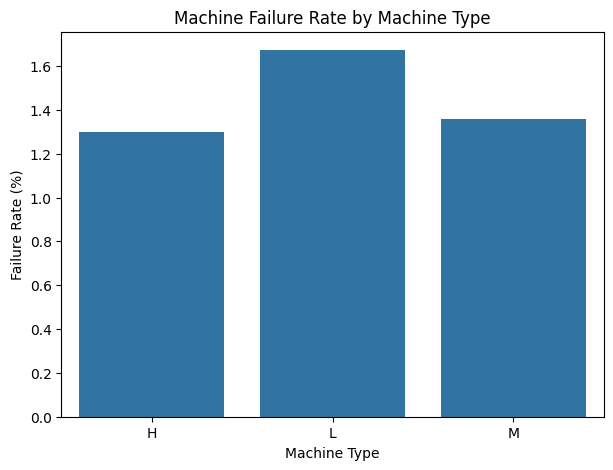

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.barplot(
    x=type_analysis.index,
    y=type_analysis["failure_rate"]
)

plt.title("Machine Failure Rate by Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Failure Rate (%)")
plt.show()

In [14]:
wear_analysis = df.groupby("wear_band")["machine_failure"].agg(
    machines="count",
    failures="sum",
    failure_rate="mean"
)

wear_analysis["failure_rate"] = wear_analysis["failure_rate"] * 100

print(wear_analysis)

           machines  failures  failure_rate
wear_band                                  
0-50          35450       423      1.193230
51-100        29370       311      1.058904
101-150       31971       352      1.100998
151-200       32197       511      1.587104
200+           7441       551      7.404919


/tmp/ipykernel_2103/2056300572.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wear_analysis = df.groupby("wear_band")["machine_failure"].agg(


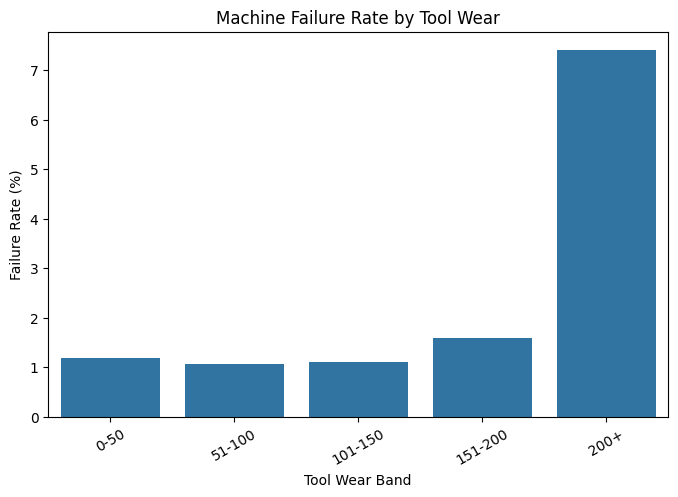

In [15]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=wear_analysis.index,
    y=wear_analysis["failure_rate"]
)

plt.title("Machine Failure Rate by Tool Wear")
plt.xlabel("Tool Wear Band")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=30)
plt.show()

In [16]:
failure_indicators = ["twf", "hdf", "pwf", "osf", "rnf"]

indicator_counts = df[failure_indicators].sum().sort_values(ascending=False)

print(indicator_counts)

hdf    704
osf    540
pwf    327
rnf    308
twf    212
dtype: int64


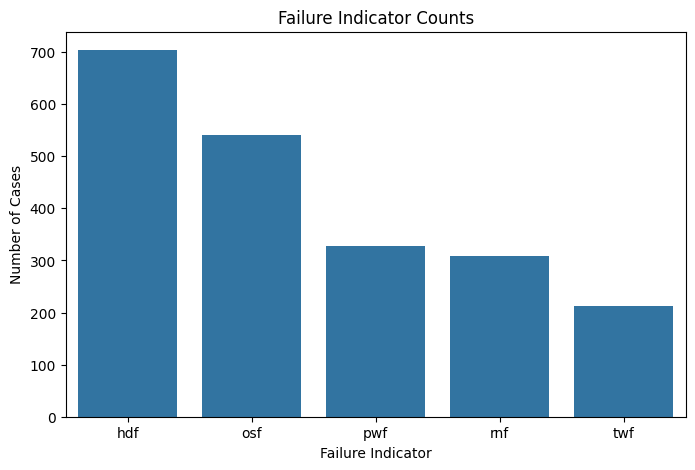

In [17]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=indicator_counts.index,
    y=indicator_counts.values
)

plt.title("Failure Indicator Counts")
plt.xlabel("Failure Indicator")
plt.ylabel("Number of Cases")
plt.show()

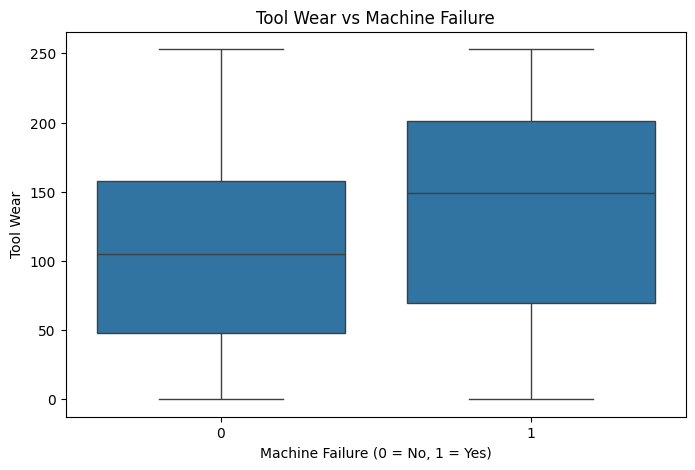

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="machine_failure",
    y="tool_wear",
    data=df
)

plt.title("Tool Wear vs Machine Failure")
plt.xlabel("Machine Failure (0 = No, 1 = Yes)")
plt.ylabel("Tool Wear")
plt.show()

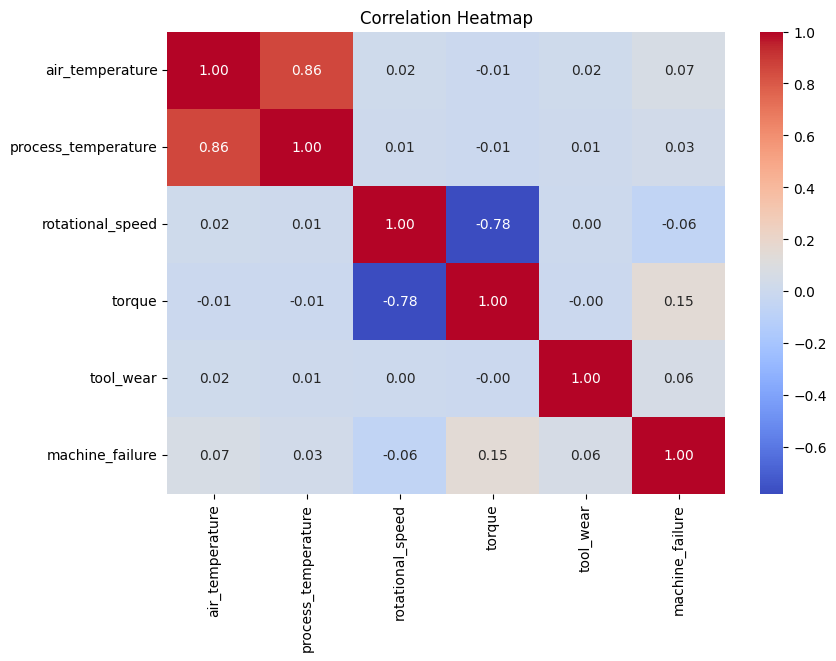

In [19]:
numeric_cols = [
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
    "machine_failure"
]

plt.figure(figsize=(9,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [20]:
machine_failure

NameError: name 'machine_failure' is not defined

In [21]:
print(df["machine_failure"].value_counts())

print("\nPercentage:")
print(df["machine_failure"].value_counts(normalize=True) * 100)

machine_failure
0    134281
1      2148
Name: count, dtype: int64

Percentage:
machine_failure
0    98.425555
1     1.574445
Name: proportion, dtype: float64


In [22]:
features = [
    "type",
    "air_temperature",
    "process_temperature",
    "rotational_speed",
    "torque",
    "tool_wear",
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

X = df[features]
y = df["machine_failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (136429, 11)
y shape: (136429,)


In [23]:
X = pd.get_dummies(X, columns=["type"], drop_first=True)

print(X.head())
print("\nNew X shape:", X.shape)


   air_temperature  process_temperature  rotational_speed  torque  tool_wear  \
0            300.6                309.6              1596    36.1        140   
1            302.6                312.1              1759    29.1        200   
2            299.3                308.5              1805    26.5         25   
3            301.0                310.9              1524    44.3        197   
4            298.0                309.0              1641    35.4         34   

   twf  hdf  pwf  osf  rnf  type_L  type_M  
0    0    0    0    0    0    True   False  
1    0    0    0    0    0   False    True  
2    0    0    0    0    0    True   False  
3    0    0    0    0    0    True   False  
4    0    0    0    0    0   False    True  

New X shape: (136429, 12)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (109143, 12)
Testing data: (27286, 12)


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [26]:
y_pred = model.predict(X_test)

print("Predictions completed!")
print(y_pred[:20])

Predictions completed!
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [27]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Probability of failure
y_probability = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.9961
Precision: 0.9601
Recall   : 0.7837
F1 Score : 0.863
ROC-AUC  : 0.9373

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     26856
           1       0.96      0.78      0.86       430

    accuracy                           1.00     27286
   macro avg       0.98      0.89      0.93     27286
weighted avg       1.00      1.00      1.00     27286



In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[26842    14]
 [   93   337]]


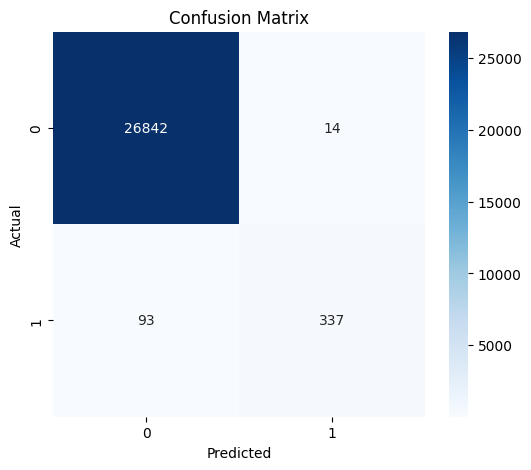

In [29]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[26842    14]
 [   93   337]]


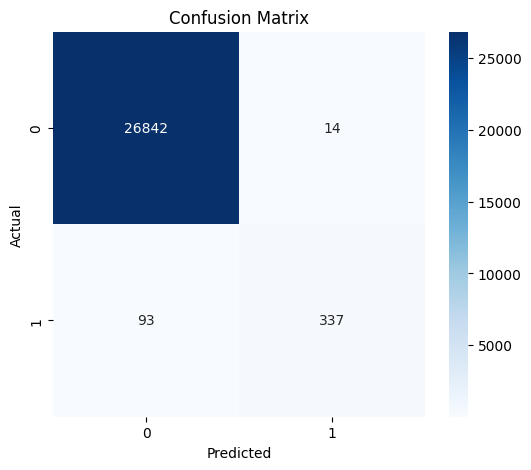

In [31]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

print(feature_importance)

                feature  importance
2      rotational_speed    0.237774
3                torque    0.193773
4             tool_wear    0.113990
6                   hdf    0.091083
8                   osf    0.087179
0       air_temperature    0.073853
7                   pwf    0.070612
5                   twf    0.068883
1   process_temperature    0.051467
10               type_L    0.006373
11               type_M    0.004492
9                   rnf    0.000520


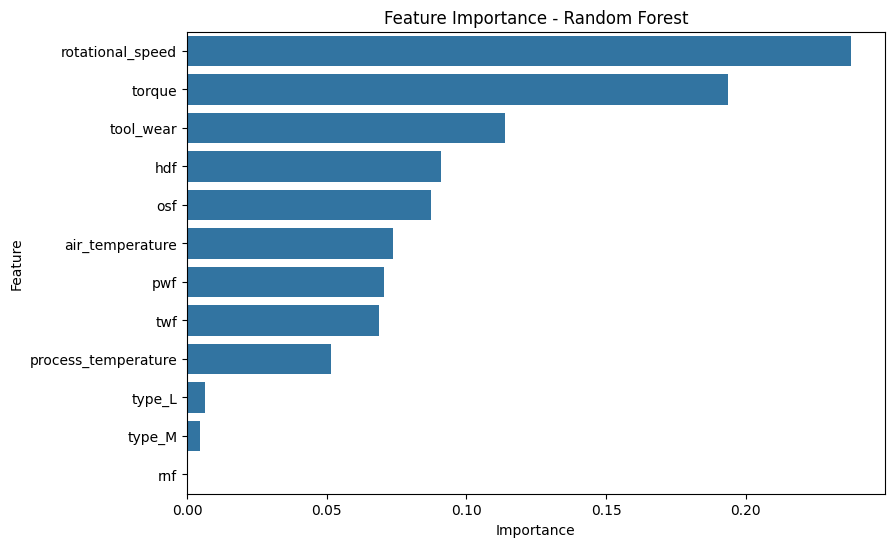

In [33]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=feature_importance,
    x="importance",
    y="feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [34]:
print(feature_importance.to_string(index=False))

            feature  importance
   rotational_speed    0.237774
             torque    0.193773
          tool_wear    0.113990
                hdf    0.091083
                osf    0.087179
    air_temperature    0.073853
                pwf    0.070612
                twf    0.068883
process_temperature    0.051467
             type_L    0.006373
             type_M    0.004492
                rnf    0.000520
